In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CASE_DIR = Path.cwd().resolve()
if CASE_DIR.name != 'PHT3D_E12':
    CASE_DIR = CASE_DIR / 'examples' / 'PHT3D_E12'
if not CASE_DIR.is_dir():
    raise FileNotFoundError(f'Cannot locate PHT3D_E12 from {Path.cwd()}')

all_results = np.load(CASE_DIR / 'output' / 'results.npy')
results = all_results[1:]
headings = np.atleast_1d(
    np.loadtxt(CASE_DIR / 'output' / 'results_headings.txt', dtype=str)
)
result_times = np.load(CASE_DIR / 'output' / 'results_times.npy')
with np.load(CASE_DIR / 'input_data' / 'official_reference.npz') as source:
    official = {name: source[name].copy() for name in source.files}

expected_times = official['actual_hours'] / 24.0
np.testing.assert_allclose(
    result_times[1:], expected_times, rtol=0.0, atol=2.0e-10
)
if results.shape != (3, len(headings), len(official['x'])):
    raise AssertionError(
        f'Unexpected result shape {results.shape}; rerun run.py'
    )

row = {name: int(np.where(headings == name)[0][0]) for name in headings}
print('MF6PQC actual output hours:', result_times[1:] * 24.0)
print('PHT3D actual output hours:', official['actual_hours'])
print('Selected-output headings:', headings.tolist())

MF6PQC actual output hours: [ 1.5086664   2.99039287 12.50046301]
PHT3D actual output hours: [ 1.5086664   2.99039286 12.50046301]
Selected-output headings: ['U_6', 'pH', 'pe', 'Tracer', 'S_aOH', 'S_bOH', 'S_cOH']


In [2]:
def profile_metrics(model, reference):
    rmse = float(np.sqrt(np.mean((model - reference) ** 2)))
    span = float(np.ptp(reference))
    nrmse = rmse / span if span > 0.0 else np.nan
    correlation = (
        float(np.corrcoef(model, reference)[0, 1])
        if np.std(model) > 0.0 and np.std(reference) > 0.0
        else np.nan
    )
    return rmse, nrmse, correlation, float(np.max(np.abs(model - reference)))

checks = {
    'U_6': {'label': 'U(VI)', 'nrmse_max': 0.080, 'corr_min': 0.970},
    'pH': {'label': 'pH', 'nrmse_max': 0.085, 'corr_min': 0.980},
    'Tracer': {'label': 'Tracer', 'nrmse_max': 0.020, 'corr_min': 0.999},
}
records = []
for field, limits in checks.items():
    for index, actual_hour in enumerate(official['actual_hours']):
        metrics = profile_metrics(
            results[index, row[field]], official[field][index]
        )
        records.append((field, index, actual_hour, *metrics))

print(f"{'field':<8} {'actual h':>11} {'NRMSE':>10} {'corr':>10} {'max |err|':>12}")
for field, index, hour, rmse, nrmse, corr, max_error in records:
    nrmse_text = f'{nrmse:.5f}' if np.isfinite(nrmse) else 'n/a'
    corr_text = f'{corr:.5f}' if np.isfinite(corr) else 'n/a'
    print(
        f'{checks[field]["label"]:<8} {hour:11.7f} '        f'{nrmse_text:>10} {corr_text:>10} {max_error:12.5g}'
    )

for field, index, hour, rmse, nrmse, corr, max_error in records:
    # The official 12.5 h tracer field is identically zero, so a span-based
    # NRMSE and correlation are undefined. Its residual is checked below.
    if field == 'Tracer' and index == 2:
        continue
    limits = checks[field]
    assert nrmse <= limits['nrmse_max'], (
        f'{limits["label"]} at {hour:g} h: NRMSE={nrmse:.5f}'
    )
    assert corr >= limits['corr_min'], (
        f'{limits["label"]} at {hour:g} h: correlation={corr:.5f}'
    )

tracer_residual = float(np.max(np.abs(results[2, row['Tracer']])))
tracer_pulse = float(np.max(official['Tracer'][:2]))
assert tracer_residual / tracer_pulse <= 0.007
print(
    f'12.5 h tracer residual = {tracer_residual:.3e} mol/L '    f'({100 * tracer_residual / tracer_pulse:.3f}% of pulse peak)'
)
print('All PHT3D cross-code acceptance checks passed.')

field       actual h      NRMSE       corr    max |err|
U(VI)      1.5086664    0.00199    0.99999   4.1123e-07
U(VI)      2.9903929    0.07334    0.97691   6.6376e-06
U(VI)     12.5004630    0.07406    0.98392   6.5585e-06
pH         1.5086664    0.01367    0.99948     0.026946
pH         2.9903929    0.04691    0.99404      0.14586
pH        12.5004630    0.08081    0.98153      0.12179
Tracer     1.5086664    0.01250    0.99924   4.9891e-08
Tracer     2.9903929    0.01198    0.99971   5.0971e-08
Tracer    12.5004630        n/a        n/a   6.2294e-09
12.5 h tracer residual = 6.229e-09 mol/L (0.623% of pulse peak)
All PHT3D cross-code acceptance checks passed.


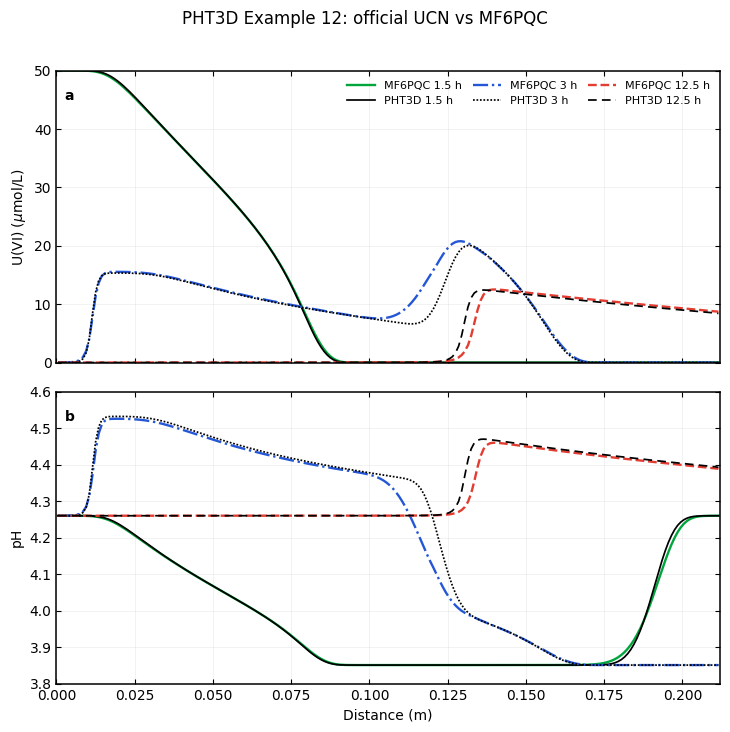

In [3]:
x = official['x']
nominal_hours = official['target_hours']
colors = ('#00a63c', '#2457d6', '#e33d32')
model_styles = ('-', '-.', '--')
reference_styles = ('-', (0, (1, 1)), (0, (5, 3)))

fig, axes = plt.subplots(2, 1, figsize=(7.4, 7.2), sharex=True)
for index, (hour, color, model_style, reference_style) in enumerate(
    zip(nominal_hours, colors, model_styles, reference_styles)
):
    axes[0].plot(
        x, results[index, row['U_6']] * 1.0e6,
        color=color, linestyle=model_style, linewidth=1.7,
        label=f'MF6PQC {hour:g} h',
    )
    axes[0].plot(
        x, official['U_6'][index] * 1.0e6,
        color='black', linestyle=reference_style, linewidth=1.25,
        label=f'PHT3D {hour:g} h',
    )
    axes[1].plot(
        x, results[index, row['pH']],
        color=color, linestyle=model_style, linewidth=1.7,
    )
    axes[1].plot(
        x, official['pH'][index],
        color='black', linestyle=reference_style, linewidth=1.25,
    )

axes[0].set_ylabel(r'U(VI) ($\mu$mol/L)')
axes[1].set_ylabel('pH')
axes[1].set_xlabel('Distance (m)')
axes[0].set_ylim(0.0, 50.0)
axes[1].set_ylim(3.8, 4.6)
axes[1].set_xlim(0.0, 0.212)
axes[0].legend(
    ncol=3, fontsize=8, frameon=False, loc='upper right',
    columnspacing=1.0, handlelength=2.5,
)
axes[0].text(0.012, 0.90, 'a', transform=axes[0].transAxes, weight='bold')
axes[1].text(0.012, 0.90, 'b', transform=axes[1].transAxes, weight='bold')
for axis in axes:
    axis.grid(alpha=0.18, linewidth=0.6)
    axis.tick_params(direction='in', top=True, right=True)
    for spine in axis.spines.values():
        spine.set_linewidth(1.1)
fig.suptitle('PHT3D Example 12: official UCN vs MF6PQC', y=1.01)
fig.tight_layout()
plt.show()